In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
import json
import re
import matplotlib.pyplot as plt

In [2]:
plot_metrics = ['hellaswag', 'lambada_openai', 'lambada_standard', 'piqa', 'truthfulqa_mc2', 'winogrande', 'arc_challenge', 'gsm8k', 'medmcqa', 'mmlu', 'paloma_wikitext_103', ]

metric_keys = [
    'acc_norm,none',
    'acc,none',
    'exact_match,strict-match',
    'exact_match,flexible-extract',
    'perplexity,none',
    'word_perplexity,none'
]

def extract_number_from_filename(filename):
    """Extract the number from filename like 'lm_eval_begin_0.json' or 'lm_eval_interval_1221.json'"""
    # Remove .json extension and split by underscore
    name_without_ext = filename.replace('.json', '')
    parts = name_without_ext.split('_')
    # The number is always the last part
    return int(parts[-1].replace('step', ''))

In [3]:
res_path = "./results/"
output_csv = './results_data.csv'
output_dir = "./figures"
os.makedirs(output_dir, exist_ok=True)

In [4]:
res_folders = os.listdir(res_path)
result_list = []
for res_folder in res_folders:
    disp_setting = re.search(r'disp-([^-]+-[^-]+)', res_folder).group(1)
    files = sorted([f for f in os.listdir(os.path.join(res_path, res_folder)) if f.startswith('lm_eval_')])
    print(f"{res_folder}")
    for file in files:
        print(f"{file}")
        step = extract_number_from_filename(file)
        with open(f'{res_path}/{res_folder}/{file}', 'r') as f:
            data = json.load(f)

        result = {}

        result['filename'] = file
        result['step'] = step
        result['disp'] = disp_setting
        
        for plot_metric in plot_metrics:
            res = data['results'][plot_metric]
            key_used = None
            for key in metric_keys:
                if key in res.keys():
                    key_used = key
                    break
            assert key_used is not None, 'no key found'
            result_value = res[key_used]
            result_key = plot_metric + ',' + key_used
            result[result_key] = result_value

        result_list.append(result)

df = pd.DataFrame(result_list).sort_values('step')
df.to_csv(output_csv, index=False)


midtrain_gpt2_Skylion007-openwebtext_lr-1e-05_token-1600000000_disp-covariance-0.5-all_fewshot-1_maxsample-200_seed-1
lm_eval_begin_0.json
lm_eval_end_12208.json
lm_eval_interval_10989.json
lm_eval_interval_1221.json
lm_eval_interval_2442.json
lm_eval_interval_3663.json
lm_eval_interval_4884.json
lm_eval_interval_6105.json
lm_eval_interval_7326.json
lm_eval_interval_8547.json
lm_eval_interval_9768.json
midtrain_gpt2_Skylion007-openwebtext_lr-1e-05_token-1600000000_disp-hinge-0.5-all_fewshot-1_maxsample-200_seed-1
lm_eval_begin_0.json
lm_eval_end_12208.json
lm_eval_interval_10989.json
lm_eval_interval_1221.json
lm_eval_interval_2442.json
lm_eval_interval_3663.json
lm_eval_interval_4884.json
lm_eval_interval_6105.json
lm_eval_interval_7326.json
lm_eval_interval_8547.json
lm_eval_interval_9768.json
midtrain_gpt2_Skylion007-openwebtext_lr-1e-05_token-1600000000_disp-infonce_cosine-0.5-all_fewshot-1_maxsample-200_seed-1
lm_eval_begin_0.json
lm_eval_end_12208.json
lm_eval_interval_10989.json

In [5]:
df

,filename,step,disp,"hellaswag,acc_norm,none","lambada_openai,acc,none","lambada_standard,acc,none","piqa,acc_norm,none","truthfulqa_mc2,acc,none","winogrande,acc,none","arc_challenge,acc_norm,none","gsm8k,exact_match,strict-match","medmcqa,acc_norm,none","mmlu,acc,none","paloma_wikitext_103,word_perplexity,none"
0,lm_eval_begin_0.json,0,covariance-0.5,0.435,0.355,0.280,0.595,0.415982,0.590,0.250,0.000,0.215,0.249156,52.286709
11,lm_eval_begin_0.json,0,hinge-0.5,0.435,0.355,0.280,0.595,0.415982,0.590,0.250,0.000,0.215,0.249156,52.286709
22,lm_eval_begin_0.json,0,infonce_cosine-0.5,0.435,0.355,0.280,0.595,0.415982,0.590,0.250,0.000,0.215,0.249156,52.286709
33,lm_eval_begin_0.json,0,None-1,0.435,0.355,0.280,0.595,0.415982,0.590,0.250,0.000,0.215,0.249156,52.286709
25,lm_eval_interval_1221.json,1221,infonce_cosine-0.5,0.430,0.360,0.275,0.605,0.422475,0.560,0.245,0.000,0.230,0.254056,54.649305
3,lm_eval_interval_1221.json,1221,covariance-0.5,0.430,0.365,0.260,0.600,0.426799,0.575,0.260,0.005,0.225,0.252967,55.114349
36,lm_eval_interval_1221.json,1221,None-1,0.430,0.375,0.270,0.585,0.417810,0.550,0.240,0.000,0.235,0.249592,55.126689
14,lm_eval_interval_1221.json,1221,hinge-0.5,0.415,0.360,0.260,0.585,0.418334,0.565,0.250,0.000,0.210,0.250463,54.511165
26,lm_eval_interval_2442.json,2442,infonce_cosine-0.5,0.430,0.385,0.265,0.605,0.420748,0.525,0.245,0.000,0.220,0.257541,54.501627
37,lm_eval_interval_2442.json,2442,None-1,0.420,0.370,0.275,0.595,0.419243,0.555,0.245,0.000,0.210,0.252423,54.674871


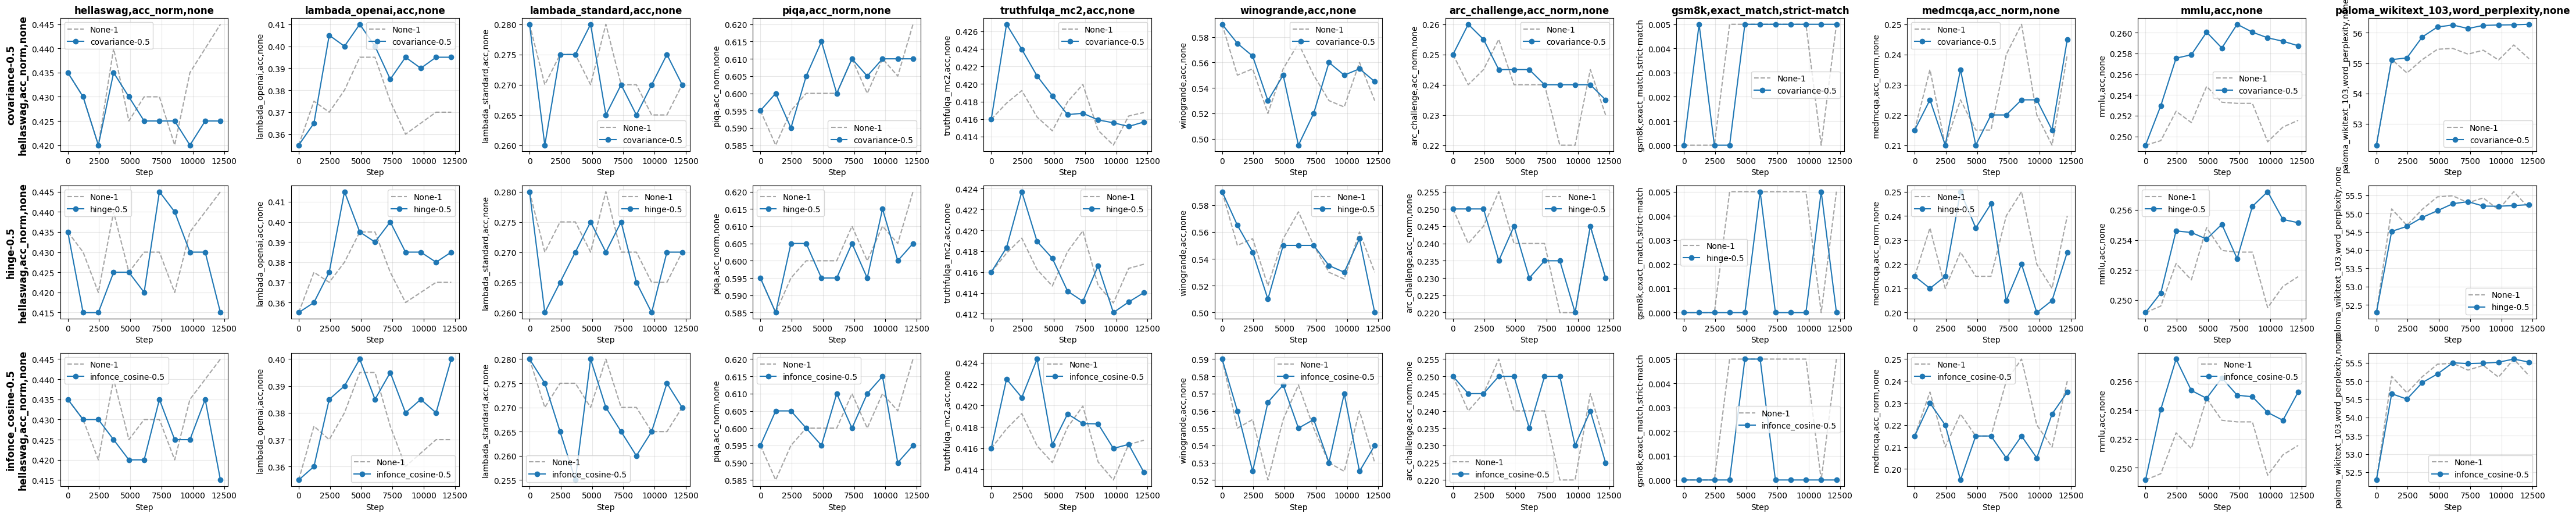

In [6]:
# Get unique dispersion methods (excluding None-1)
disp_methods = [d for d in df['disp'].unique() if d != 'None-1']
# Get metric columns (excluding filename, step, disp)
metric_cols = [col for col in df.columns if col not in ['filename', 'step', 'disp']]

# Create subplots
fig, axes = plt.subplots(len(disp_methods), len(metric_cols), 
                        figsize=(4*len(metric_cols), 3*len(disp_methods)))

# Ensure axes is 2D array
if len(disp_methods) == 1:
    axes = axes.reshape(1, -1)
if len(metric_cols) == 1:
    axes = axes.reshape(-1, 1)

# Get baseline data (None-1)
baseline_data = df[df['disp'] == 'None-1']

# Plot for each dispersion method and metric
for i, disp in enumerate(disp_methods):
    for j, metric in enumerate(metric_cols):
        ax = axes[i, j]
        
        # Plot baseline (None-1) as gray dashed line
        if not baseline_data.empty:
            ax.plot(baseline_data['step'], baseline_data[metric], 
                   color='gray', linestyle='--', alpha=0.7, label='None-1')
        
        # Plot current dispersion method
        method_data = df[df['disp'] == disp]
        if not method_data.empty:
            ax.plot(method_data['step'], method_data[metric], 
                   marker='o', label=disp)
        
        # Set labels and title
        ax.set_xlabel('Step')
        ax.set_ylabel(metric)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add column labels on top row
        if i == 0:
            ax.set_title(metric, fontsize=12, fontweight='bold')
    
    # Add row labels on left column
    if len(metric_cols) > 0:
        axes[i, 0].set_ylabel(f'{disp}\n{metric_cols[0]}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
df[df['step'] == 0]#[['arc_challenge,acc_norm,none']]

,filename,step,disp,"hellaswag,acc_norm,none","lambada_openai,acc,none","lambada_standard,acc,none","piqa,acc_norm,none","truthfulqa_mc2,acc,none","winogrande,acc,none","arc_challenge,acc_norm,none","gsm8k,exact_match,strict-match","medmcqa,acc_norm,none","mmlu,acc,none","paloma_wikitext_103,word_perplexity,none"
0,lm_eval_begin_0.json,0,covariance-0.5,0.435,0.355,0.28,0.595,0.415982,0.59,0.25,0.0,0.215,0.249156,52.286709
11,lm_eval_begin_0.json,0,hinge-0.5,0.435,0.355,0.28,0.595,0.415982,0.59,0.25,0.0,0.215,0.249156,52.286709
22,lm_eval_begin_0.json,0,infonce_cosine-0.5,0.435,0.355,0.28,0.595,0.415982,0.59,0.25,0.0,0.215,0.249156,52.286709
33,lm_eval_begin_0.json,0,None-1,0.435,0.355,0.28,0.595,0.415982,0.59,0.25,0.0,0.215,0.249156,52.286709


In [14]:
best = df.groupby('disp').max()[[c for c in df.columns if c not in ['disp', 'filename', 'step', 'paloma_wikitext_103,word_perplexity,none']]]

In [15]:
best

,"hellaswag,acc_norm,none","lambada_openai,acc,none","lambada_standard,acc,none","piqa,acc_norm,none","truthfulqa_mc2,acc,none","winogrande,acc,none","arc_challenge,acc_norm,none","gsm8k,exact_match,strict-match","medmcqa,acc_norm,none","mmlu,acc,none"
disp,,,,,,,,,,
None-1,0.445,0.395,0.28,0.620,0.419945,0.59,0.255,0.005,0.250,0.254819
covariance-0.5,0.435,0.410,0.28,0.615,0.426799,0.59,0.260,0.005,0.245,0.260808
hinge-0.5,0.445,0.415,0.28,0.615,0.423708,0.59,0.250,0.005,0.250,0.257214
infonce_cosine-0.5,0.435,0.400,0.28,0.615,0.424347,0.59,0.250,0.005,0.235,0.257541


In [18]:
best_diff = best - best.iloc[0]
best_diff * 100

,"hellaswag,acc_norm,none","lambada_openai,acc,none","lambada_standard,acc,none","piqa,acc_norm,none","truthfulqa_mc2,acc,none","winogrande,acc,none","arc_challenge,acc_norm,none","gsm8k,exact_match,strict-match","medmcqa,acc_norm,none","mmlu,acc,none"
disp,,,,,,,,,,
None-1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
covariance-0.5,-1.0,1.5,0.0,-0.5,0.685426,0.0,0.5,0.0,-0.5,0.598933
hinge-0.5,0.0,2.0,0.0,-0.5,0.376304,0.0,-0.5,0.0,0.0,0.239573
infonce_cosine-0.5,-1.0,0.5,0.0,-0.5,0.440207,0.0,-0.5,0.0,-1.5,0.272242
